# 🚢 Titanic Mini Visualization Dashboard
### Data Science with Python Internship — Task 4

A single-notebook dashboard that cleans the Titanic dataset, engineers a couple of
simple features, and tells a short visual data story across five chart types.

**Dataset:** Titanic (Kaggle) — 891 passengers, 12 columns
**Libraries:** pandas, numpy, seaborn, matplotlib


## 1. Overview

The Titanic dataset records passenger-level details (age, sex, class, fare, family
relations) along with whether each passenger survived the 1912 sinking. Our goal in
this notebook is to explore **who survived, and why** — using cleaning, light feature
engineering, and five distinct chart types, each followed by a short interpretation.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (8, 5)

import os
os.makedirs("images", exist_ok=True)


In [2]:
df = pd.read_csv("data/titanic.csv")
print("Shape:", df.shape)
df.head()


Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


**First look:** We have 891 rows and 12 columns. `Age`, `Cabin`, and `Embarked`
contain missing values that need to be handled before we can plot or model anything
reliably. `Cabin` is missing for the majority of passengers, so it isn't very useful
in its raw form for this dashboard.


In [4]:
df.isnull().sum().sort_values(ascending=False)


Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64

## 2. Cleaning

Steps:
- Fill missing **Age** with the **median** age (robust to the right-skew in age).
- Fill missing **Embarked** with the **mode** (only 2 rows affected).
- Drop the **Cabin** column (77%+ missing — not reliable for this analysis).


In [5]:
# Fill missing Age values with the median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing Embarked with the mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop the mostly-empty Cabin column
df = df.drop(columns=["Cabin"], errors="ignore")

# Confirm there are no more missing values in the columns we'll use
df.isnull().sum()


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## 3. Feature Engineering

Two simple, high-value features:
- **FamilySize** = `SibSp` + `Parch` (+1 for the passenger themself) — captures whether
  someone was travelling alone or with family.
- **AgeGroup** — bins raw age into Child / Teen / YoungAdult / Adult / Senior, which is
  easier to read on bar charts than raw continuous age.


In [6]:
# FamilySize: siblings/spouses + parents/children + the passenger themself
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

# AgeGroup: bucket continuous age into readable categories
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 12, 18, 30, 50, 80],
    labels=["Child", "Teen", "YoungAdult", "Adult", "Senior"]
)

df[["Age", "AgeGroup", "SibSp", "Parch", "FamilySize"]].head()


,Age,AgeGroup,SibSp,Parch,FamilySize
0,22.0,YoungAdult,1,0,2
1,38.0,Adult,1,0,2
2,26.0,YoungAdult,0,0,1
3,35.0,Adult,1,0,2
4,35.0,Adult,0,0,1


## 4. Visualizations

Five chart types, each with a short takeaway underneath.


### 4.1 Histogram — Age Distribution

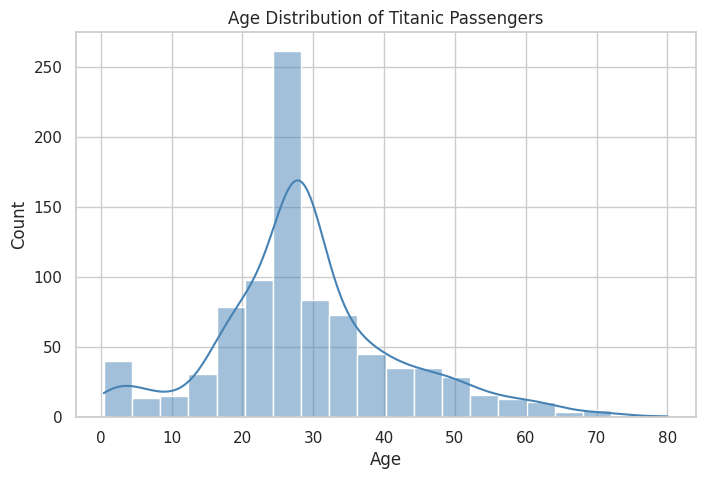

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=20, kde=True, color="steelblue")
plt.title("Age Distribution of Titanic Passengers")
plt.xlabel("Age")
plt.ylabel("Count")
plt.savefig("images/01_age_histogram.png", dpi=150, bbox_inches="tight")
plt.show()


**Insight:** Most passengers were young adults in their 20s–30s, with a visible
spike near the median-filled age (~28) from our missing-value imputation. There's a
smaller secondary bump for young children under 10.


### 4.2 Bar Chart — Survival Rate by Sex and Class

/tmp/ipykernel_570/2865762446.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Sex", y="Survived", data=df, ax=axes[0], palette="Set2")
/tmp/ipykernel_570/2865762446.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Pclass", y="Survived", data=df, ax=axes[1], palette="Set2")


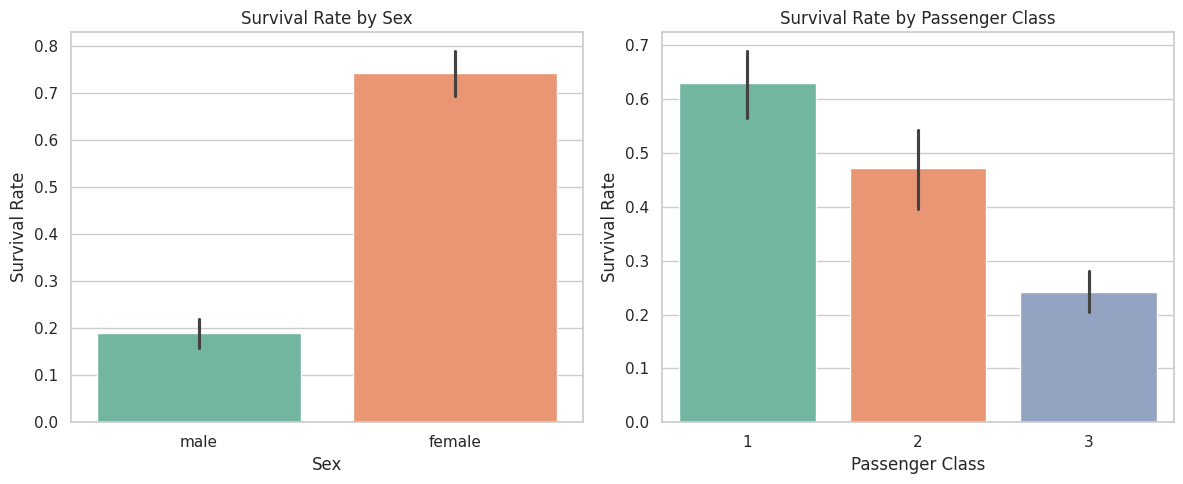

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.barplot(x="Sex", y="Survived", data=df, ax=axes[0], palette="Set2")
axes[0].set_title("Survival Rate by Sex")
axes[0].set_ylabel("Survival Rate")

sns.barplot(x="Pclass", y="Survived", data=df, ax=axes[1], palette="Set2")
axes[1].set_title("Survival Rate by Passenger Class")
axes[1].set_xlabel("Passenger Class")
axes[1].set_ylabel("Survival Rate")

plt.tight_layout()
plt.savefig("images/02_survival_by_sex_class.png", dpi=150, bbox_inches="tight")
plt.show()


**Insight:** Women survived at a far higher rate than men (roughly 3x), reflecting
the "women and children first" evacuation priority. Survival also drops sharply as
class number increases — 1st class passengers survived at nearly double the rate of
3rd class passengers, likely due to cabin location and lifeboat access.


### 4.3 Boxplot — Fare Distribution by Passenger Class

/tmp/ipykernel_570/1228720012.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Pclass", y="Fare", data=df, palette="coolwarm")


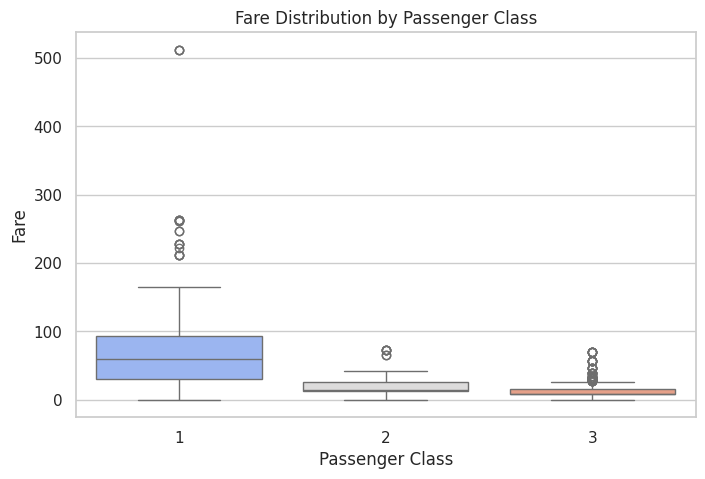

In [9]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Pclass", y="Fare", data=df, palette="coolwarm")
plt.title("Fare Distribution by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.savefig("images/03_fare_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()


**Insight:** 1st class fares are much higher and more spread out, with several
extreme outliers above $250 — likely large family bookings or premium suites. 2nd and
3rd class fares are tightly clustered near the bottom, confirming fare closely tracks
class (and, by extension, survival odds).


### 4.4 Scatterplot — Age vs Fare, colored by Survival

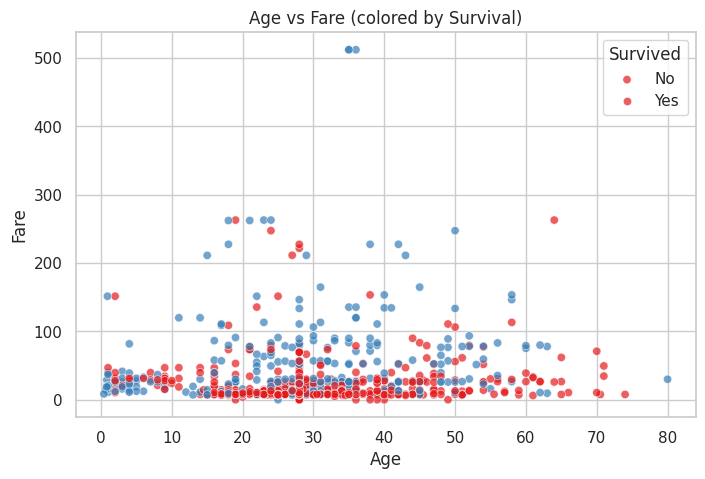

In [10]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="Age", y="Fare", hue="Survived", data=df, alpha=0.7, palette="Set1")
plt.title("Age vs Fare (colored by Survival)")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.legend(title="Survived", labels=["No", "Yes"])
plt.savefig("images/04_age_vs_fare_scatter.png", dpi=150, bbox_inches="tight")
plt.show()


**Insight:** Survivors (orange) are noticeably concentrated at higher fare levels
across most ages, reinforcing that wealthier passengers (higher fare, likely 1st
class) had better survival odds regardless of age. Most of the very low-fare, low-age
points skew toward non-survival.


### 4.5 Heatmap — Correlation of Numeric Features

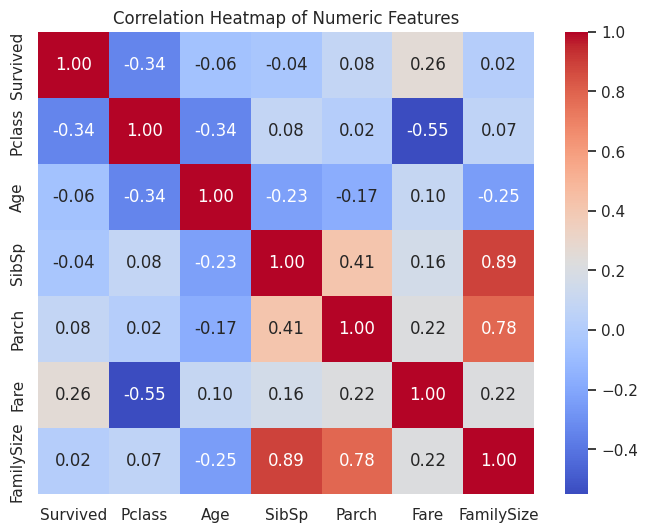

In [11]:
numeric_cols = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare", "FamilySize"]
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.savefig("images/05_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


**Insight:** `Survived` correlates negatively with `Pclass` (-0.34) — lower class
number (better class) associates with higher survival — and positively with `Fare`
(0.26), consistent with the class/fare pattern seen above. `FamilySize` has only a
weak relationship with survival, suggesting family size alone isn't a strong
predictor on its own.


### Bonus — Facet Grid: Survival by Class, split by Sex

/tmp/ipykernel_570/1520949211.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


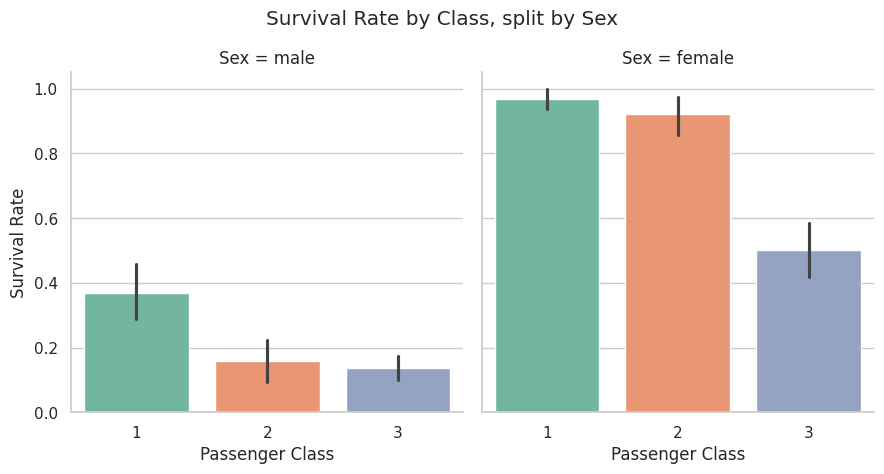

In [12]:
g = sns.catplot(
    data=df, x="Pclass", y="Survived", col="Sex",
    kind="bar", palette="Set2", height=4.5, aspect=1
)
g.fig.suptitle("Survival Rate by Class, split by Sex", y=1.05)
g.set_axis_labels("Passenger Class", "Survival Rate")
g.savefig("images/06_facet_survival_class_sex.png", dpi=150, bbox_inches="tight")
plt.show()


**Insight:** The class effect holds within both sexes, but is much more dramatic
for men — male survival collapses from 1st to 3rd class, while female survival stays
relatively high across all three classes and only dips modestly in 3rd class.


## 5. Key Insights Summary

1. **Sex was the strongest single factor** — women survived at roughly 3x the rate of men.
2. **Class mattered a lot, especially for men** — 1st class passengers (of either sex) fared far better than 3rd class.
3. **Fare tracks survival** — higher fares (a proxy for class and cabin location) associate with better survival odds.
4. **Age had a smaller, secondary effect** — young children had somewhat better odds, but age alone is a weak predictor compared to sex and class.
5. **Family size shows only a weak correlation with survival** — traveling with a small family showed a slight edge over traveling completely alone or in very large groups, but the effect is minor next to sex/class/fare.


## 6. Conclusion

This dashboard shows that survival on the Titanic was driven primarily by **sex** and
**socioeconomic class** (as proxied by passenger class and fare), with age and family
size playing smaller, secondary roles. The combination of a histogram, bar charts,
boxplot, scatterplot, and correlation heatmap — plus one bonus facet grid — gives a
well-rounded visual story of the dataset from five different analytical angles.

**Next steps:** this cleaned/engineered dataframe would be a solid starting point for
a simple classification model (e.g., logistic regression or a decision tree) predicting
`Survived` from `Sex`, `Pclass`, `Fare`, and `AgeGroup`.
